# Final Project - Wind Turbine Fault Detection

This notebook consolidates the project into a single, submission-ready workflow that runs from raw data validation through preprocessing, exploratory analysis, modeling, evaluation, and artifact generation.

## Notebook goals
- Show the **full data analysis pipeline** in one place for submission.
- Reuse the modular `wtfd` package instead of duplicating implementation details.
- Add **artifact guards** so repeated notebook execution does not unnecessarily rerun expensive preprocessing or modeling steps.
- Preserve the real project structure while still satisfying the course requirement for a single notebook.

## Project framing
This is a **time series predictive maintenance** problem using wind turbine SCADA data. The objective is to predict whether a turbine is approaching a fault event within a given lead window. The preprocessing pipeline creates canonical event-state labels, and the modeling workflow compares three operational prediction horizons:

- **pre_24h**
- **pre_48h**
- **pre_72h**

The notebook keeps the real-world modular architecture intact, but presents the work in a linear, well-documented form appropriate for course submission.


## How this notebook is organized

1. Set up the environment and resolve project paths  
2. Validate the repository structure and required inputs  
3. Reuse existing processed artifacts when possible, or run preprocessing if needed  
4. Inspect the processed dataset and create report-ready visual diagnostics  
5. Run or reuse modeling experiments for the 24h, 48h, and 72h horizons  
6. Generate the core report figures and tables with consistent saved filenames  
7. Run a lightweight fresh diagnostic model only when needed for prediction timelines and validation-threshold plots  
8. Summarize conclusions and reproducibility notes

> **Important:** This notebook is intentionally defensive. Expensive steps check for existing outputs before rebuilding them.

In [1]:
# Optional notebook convenience magics.
# These can be commented out if your environment does not support IPython magics.
%load_ext autoreload
%autoreload 2


In [30]:
from __future__ import annotations

import gc
import json
import sys
from pathlib import Path
from typing import Any, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import seaborn as sns
sns.set_style("white")
from IPython.display import Markdown, display
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import PercentFormatter

In [3]:
def find_project_root(start: Optional[Path] = None) -> Path:
    """Walk upward until a repository root is found."""
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the ML_Project repository."
    )

PROJECT_ROOT = find_project_root()
SRC_ROOT = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print(f"Source root:  {SRC_ROOT}")


Project root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project
Source root:  /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/src


In [4]:
# Optional editable install for environments where the package has not been installed yet.
# Set to True only if imports fail below and you want the notebook to install the local package.
ENABLE_EDITABLE_INSTALL_IF_NEEDED = False

if ENABLE_EDITABLE_INSTALL_IF_NEEDED:
    import subprocess
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-e", str(PROJECT_ROOT)],
        check=True,
    )


In [5]:
from wtfd.data.preprocessing import WindFarmProcessor
from wtfd.models.artifacts import (
    ensure_run_output_dir,
    load_dataframe_artifact,
    load_json_artifact,
    save_dataframe_artifact,
    save_feature_importance,
    save_model_metrics,
    save_run_metadata,
    save_threshold_sweep,
)
from wtfd.models.experiments import get_experiment_config, list_available_experiments
from wtfd.models.feature_selector import (
    build_feature_matrix,
    summarize_feature_selection,
    validate_no_leakage_columns_in_features,
)
from wtfd.models.metrics import build_threshold_sweep_table
from wtfd.models.model_registry import get_model_config, list_available_models
from wtfd.models.splitter import WindFarmSplitter
from wtfd.models.trainer import WindFaultTrainer
from wtfd.utils.logging_utils import get_logger

logger = get_logger("wtfd.notebooks.final_project")

try:
    import xgboost  # noqa: F401
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Available experiments:", list_available_experiments())
print("Available models:", list_available_models())
print("XGBoost available:", HAS_XGBOOST)


Available experiments: ['pre_24h', 'pre_48h', 'pre_72h']
Available models: ['logistic', 'rf', 'xgboost']
XGBoost available: True


## Notebook controls

The next cell contains the main notebook toggles. These are separated from the execution logic so the notebook remains easy to rerun during testing.

Recommended default behavior for submission:
- **reuse existing processed artifacts**
- **reuse existing modeling artifacts when available**
- **save fresh modeling outputs only when needed**


In [6]:
# ------------------------------------------------------------------
# Project paths
# ------------------------------------------------------------------
CONFIG_PATH = PROJECT_ROOT / "config" / "feature_map.yaml"
RAW_DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "zenodo_windfarm_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MASTER_DATASET_PATH = PROCESSED_DIR / "master_dataset.parquet"
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / "modeling"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TIMELINE_DIR = OUTPUT_DIR / "failure_timelines"
REPORT_FIG_DIR = OUTPUT_DIR / "final_report_figures"
REPORT_DIAGNOSTICS_DIR = PROJECT_ROOT / "artifacts" / "report_diagnostics"

# ------------------------------------------------------------------
# Preprocessing controls
# ------------------------------------------------------------------
# NOTE:
# The WTDF preprocessing code supports a pre-window exclusion buffer
# immediately before the earliest 72h positive window and a post-event
# exclusion buffer immediately after the event window ends.
BUFFER_BEFORE_HOURS = 4.0
BUFFER_AFTER_HOURS = 4.0
REBUILD_EVENT_PARQUETS = False
REBUILD_MASTER_DATASET = False

# ------------------------------------------------------------------
# Data inspection controls
# ------------------------------------------------------------------
SAMPLE_N_ROWS = 5000
HARMONIZATION_FEATURE_COUNT = 13
FORCE_REBUILD_HARMONIZATION_CACHE = False
HARMONIZATION_CACHE_PATH = REPORT_DIAGNOSTICS_DIR / "feature_harmonization_overview.csv"

# ------------------------------------------------------------------
# Modeling controls
# ------------------------------------------------------------------
EXPERIMENT_NAMES = ["pre_24h", "pre_48h", "pre_72h"]
MODEL_NAMES_OVERRIDE = None     # e.g. ["logistic", "rf", "xgboost"]
NUMERIC_ONLY = True
FEATURE_SUBSET = None
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42
REUSE_SAVED_MODEL_ARTIFACTS = True
SAVE_FRESH_MODELING_ARTIFACTS = False

# ------------------------------------------------------------------
# Report-specific controls
# ------------------------------------------------------------------
REPORT_EXPERIMENT_NAME = "pre_72h"
REPORT_MODEL_NAME = "xgboost"
FORCE_REBUILD_REPORT_DIAGNOSTICS = False
SAVE_REPORT_FIGURES = True
TABLE_DECIMALS = 3

# ------------------------------------------------------------------
# Visualization controls
# ------------------------------------------------------------------
TIMELINE_SIGNALS = [
    "vibration_raw",
    "nacelle_temp",
    "temp_delta_gearbox",
]
TIMELINE_HOURS_BEFORE = 168
TIMELINE_HOURS_AFTER = 24
TOP_N_FEATURES = 15

# Conceptual display only for Figure 1. This is not a data-derived duration.
FIG_1_EVENT_WINDOW_HOURS = 4.0

## Validate required repository inputs

This step confirms that the repository layout matches the expected project structure. It also reports whether processed artifacts already exist, which determines whether the notebook can skip expensive preprocessing steps.


In [7]:
required_paths = {
    "config": CONFIG_PATH,
    "raw_data_root": RAW_DATA_ROOT,
    "processed_dir": PROCESSED_DIR,
    "artifact_root": ARTIFACT_ROOT,
    "output_dir": OUTPUT_DIR,
    "report_fig_dir": REPORT_FIG_DIR,
    "report_diagnostics_dir": REPORT_DIAGNOSTICS_DIR,
}

for path_name, path_value in required_paths.items():
    print(f"{path_name:>22}: {path_value} | exists={path_value.exists()}")

assert CONFIG_PATH.exists(), f"Missing config file: {CONFIG_PATH}"
assert RAW_DATA_ROOT.exists(), f"Missing raw data root: {RAW_DATA_ROOT}"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TIMELINE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIAGNOSTICS_DIR.mkdir(parents=True, exist_ok=True)

event_parquet_files = sorted(
    [p for p in PROCESSED_DIR.glob("*.parquet") if p.name != "master_dataset.parquet"]
)


def processed_dataset_has_excluded_buffer_rows(parquet_files: list[Path]) -> bool:
    """Return True if any processed event parquet contains excluded-buffer rows."""
    for parquet_path in parquet_files:
        try:
            buffer_df = pd.read_parquet(parquet_path, columns=["is_excluded_buffer"])
            if "is_excluded_buffer" in buffer_df.columns and buffer_df["is_excluded_buffer"].fillna(False).any():
                return True
        except Exception:
            try:
                state_df = pd.read_parquet(parquet_path, columns=["state_name"])
                if "state_name" in state_df.columns and state_df["state_name"].astype(str).eq("excluded_buffer").any():
                    return True
            except Exception:
                continue
    return False


existing_buffer_rows_present = (
    processed_dataset_has_excluded_buffer_rows(event_parquet_files)
    if event_parquet_files
    else False
)

repo_summary_df = pd.DataFrame(
    [
        {"item": "event parquet files", "count": len(event_parquet_files)},
        {"item": "master dataset exists", "count": int(MASTER_DATASET_PATH.exists())},
        {"item": "artifact experiment folders", "count": sum(1 for p in ARTIFACT_ROOT.glob("*") if p.is_dir())},
        {"item": "report figure directory", "count": int(REPORT_FIG_DIR.exists())},
        {"item": "existing excluded_buffer rows detected", "count": int(existing_buffer_rows_present)},
    ]
)
display(repo_summary_df)

if event_parquet_files and (BUFFER_BEFORE_HOURS > 0 or BUFFER_AFTER_HOURS > 0) and not existing_buffer_rows_present:
    print(
        "Configured notebook uses nonzero exclusion buffers, but the existing processed "
        "event parquet files contain no excluded_buffer rows. Forcing a preprocessing "
        "rebuild so the notebook, figure logic, and underlying labels stay aligned."
    )
    REBUILD_EVENT_PARQUETS = True
    REBUILD_MASTER_DATASET = True
    REUSE_SAVED_MODEL_ARTIFACTS = False
    FORCE_REBUILD_REPORT_DIAGNOSTICS = True

print()
print(f"BUFFER_BEFORE_HOURS = {BUFFER_BEFORE_HOURS}")
print(f"BUFFER_AFTER_HOURS  = {BUFFER_AFTER_HOURS}")
print(f"REBUILD_EVENT_PARQUETS = {REBUILD_EVENT_PARQUETS}")
print(f"REBUILD_MASTER_DATASET = {REBUILD_MASTER_DATASET}")
print(f"REUSE_SAVED_MODEL_ARTIFACTS = {REUSE_SAVED_MODEL_ARTIFACTS}")
print(f"FORCE_REBUILD_REPORT_DIAGNOSTICS = {FORCE_REBUILD_REPORT_DIAGNOSTICS}")

                config: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/config/feature_map.yaml | exists=True
         raw_data_root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/raw/zenodo_windfarm_data | exists=True
         processed_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/processed | exists=True
         artifact_root: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling | exists=True
            output_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs | exists=True
        report_fig_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures | exists=True
report_diagnostics_dir: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/report_diagnostics | exists=True


,item,count
0,event parquet files,95
1,master dataset exists,1
2,artifact experiment folders,3
3,report figure directory,1
4,existing excluded_buffer rows detected,1



BUFFER_BEFORE_HOURS = 4.0
BUFFER_AFTER_HOURS  = 4.0
REBUILD_EVENT_PARQUETS = False
REBUILD_MASTER_DATASET = False
REUSE_SAVED_MODEL_ARTIFACTS = True
FORCE_REBUILD_REPORT_DIAGNOSTICS = False


## Methodology summary

### Data processing strategy
The preprocessing pipeline standardizes farm-specific SCADA inputs into a consistent schema, normalizes units, creates derived features, and assigns canonical event-state labels. This design keeps the processed dataset flexible enough to support multiple prediction windows without rerunning the full preprocessing pipeline each time.

### Modeling strategy
Three experiments are evaluated: **24-hour**, **48-hour**, and **72-hour** lead windows. Each experiment uses the same processed base table but redefines the positive class according to the canonical state labels. This makes the comparison between horizons fair and reproducible.

### Algorithms
The notebook compares three models already registered in the project:
- **Logistic Regression** for a simple, interpretable baseline
- **Random Forest** for a non-linear tree-based baseline
- **XGBoost** for a stronger gradient boosting candidate when available

### Split strategy
The default split is **event-level chronological splitting**, which keeps whole events in the same split while preserving temporal order. That reduces leakage and better reflects real deployment conditions.


## Initialize the preprocessing pipeline

The processor reads the YAML feature map, standardizes raw inputs, engineers derived features, and produces event-level Parquet files plus the consolidated master dataset.


In [8]:
processor = WindFarmProcessor(
    config_path=CONFIG_PATH,
    buffer_before_hours=BUFFER_BEFORE_HOURS,
    buffer_after_hours=BUFFER_AFTER_HOURS,
)

processor


2026-04-14 17:11:24 | INFO | wtfd.data.preprocessing | Initialized WindFarmProcessor with config_path=/mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/config/feature_map.yaml, buffer_before_hours=4.0, buffer_after_hours=4.0


## Run preprocessing only when needed

The notebook reuses existing outputs unless the rebuild flags are enabled. This keeps iterative notebook testing practical while still preserving the full data processing logic required by the assignment.


In [9]:
if REBUILD_EVENT_PARQUETS or not event_parquet_files:
    logger.info("Running event-level preprocessing.")
    processor.process_all_turbines(
        raw_data_root=RAW_DATA_ROOT,
        output_dir=PROCESSED_DIR,
    )
    event_parquet_files = sorted(
        [p for p in PROCESSED_DIR.glob("*.parquet") if p.name != "master_dataset.parquet"]
    )
else:
    logger.info("Reusing existing event-level parquet files.")
    print(f"Reusing {len(event_parquet_files)} event-level parquet files from {PROCESSED_DIR}")

if REBUILD_MASTER_DATASET or not MASTER_DATASET_PATH.exists():
    if not event_parquet_files:
        raise FileNotFoundError(
            "No event-level parquet files are available, so the master dataset cannot be built."
        )
    logger.info("Building consolidated master dataset.")
    master_dataset_output = processor.create_master_dataset(
        processed_dir=PROCESSED_DIR,
        output_path=MASTER_DATASET_PATH,
    )
    print(f"Master dataset created: {master_dataset_output}")
else:
    logger.info("Reusing existing master dataset.")
    print(f"Reusing existing master dataset: {MASTER_DATASET_PATH}")

assert MASTER_DATASET_PATH.exists(), f"Master dataset not found: {MASTER_DATASET_PATH}"


2026-04-14 17:11:24 | INFO | wtfd.notebooks.final_project | Reusing existing event-level parquet files.
2026-04-14 17:11:24 | INFO | wtfd.notebooks.final_project | Reusing existing master dataset.


Reusing 95 event-level parquet files from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/processed
Reusing existing master dataset: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/data/processed/master_dataset.parquet


## Review generated preprocessing artifacts

The event-level Parquet files preserve event granularity, while the master dataset supports modeling and consolidated inspection. The next cells summarize what was produced and inspect the schema without loading the entire dataset into memory.


In [10]:
event_file_summary = pd.DataFrame(
    {
        "file_name": [p.name for p in event_parquet_files],
        "size_mb": [round(p.stat().st_size / (1024 ** 2), 3) for p in event_parquet_files],
    }
).sort_values("file_name").reset_index(drop=True)

display(event_file_summary.head(10))

master_parquet = pq.ParquetFile(MASTER_DATASET_PATH)
print(f"Master dataset row groups: {master_parquet.num_row_groups}")
print("Master dataset schema:")
print(master_parquet.schema)


,file_name,size_mb
0,A_event_0.parquet,7.362
1,A_event_10.parquet,7.208
2,A_event_13.parquet,7.201
3,A_event_14.parquet,7.330
4,A_event_17.parquet,7.416
5,A_event_22.parquet,7.061
6,A_event_24.parquet,7.407
7,A_event_25.parquet,7.373
8,A_event_26.parquet,7.203
9,A_event_3.parquet,7.455


Master dataset row groups: 96
Master dataset schema:
required group field_id=-1 schema {
  optional int64 field_id=-1 time_stamp (Timestamp(isAdjustedToUTC=false, timeUnit=nanoseconds, is_from_converted_type=false, force_set_converted_type=false));
  optional binary field_id=-1 farm_id (String);
  optional binary field_id=-1 asset_id (String);
  optional double field_id=-1 amb_temp;
  optional double field_id=-1 wind_speed;
  optional double field_id=-1 pitch_angle;
  optional double field_id=-1 active_power;
  optional double field_id=-1 gen_speed;
  optional double field_id=-1 gearbox_oil_temp;
  optional double field_id=-1 transformer_temp;
  optional double field_id=-1 nacelle_temp;
  optional double field_id=-1 hub_temp;
  optional double field_id=-1 yaw_error;
  optional double field_id=-1 vibration_raw;
  optional double field_id=-1 hydraulic_temp;
  optional double field_id=-1 generator_temp;
  optional double field_id=-1 temp_delta_gearbox;
  optional double field_id=-1 temp_t

## Load a small sample for exploratory inspection

A small sample is used for fast diagnostics. This keeps the notebook responsive while still allowing us to validate labels, feature availability, and data quality before modeling.


In [11]:
sample_batches = []
rows_loaded = 0

for batch in master_parquet.iter_batches(batch_size=SAMPLE_N_ROWS):
    sample_batches.append(batch)
    rows_loaded += batch.num_rows
    if rows_loaded >= SAMPLE_N_ROWS:
        break

sample_df = pa.Table.from_batches(sample_batches).slice(0, SAMPLE_N_ROWS).to_pandas()

print(f"Loaded {len(sample_df):,} sample rows from {MASTER_DATASET_PATH.name}")
display(sample_df.head())
print()
sample_df.info()


Loaded 5,000 sample rows from master_dataset.parquet


,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,generator_temp,temp_delta_gearbox,temp_trend_24h,rpm_volatility,temp_divergence,power_efficiency,vibration_magnitude,gearbox_oil_temp_delta_6,gearbox_oil_temp_volatility_6,gearbox_oil_temp_delta_24,gearbox_oil_temp_volatility_24,generator_temp_delta_6,generator_temp_volatility_6,generator_temp_delta_24,generator_temp_volatility_24,active_power_delta_6,active_power_volatility_6,active_power_delta_24,active_power_volatility_24,yaw_error_delta_6,yaw_error_volatility_6,yaw_error_delta_24,yaw_error_volatility_24,event_id,event_label,event_start,event_end,state_label,state_name,is_excluded_buffer,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.3,41.0,66.333333,30.0,31.0,129.4,22.1,41.0,31.5,19.0,0.0,0.0,-1.0,-0.521067,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.0,41.0,66.333333,30.0,31.0,133.6,0.0,41.0,31.5,19.0,0.0,0.0,-1.0,-0.520252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.8,41.0,66.333333,30.0,31.0,167.1,5.8,41.0,31.5,19.0,0.0,0.0,-1.0,-3.720165,5.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
3,2022-08-04 06:40:00,A,0,22.0,1.5,24.0,-2.548,0.4,41.0,66.000000,29.0,30.0,-49.1,1.9,41.0,31.5,19.0,0.0,0.0,-1.0,-0.754963,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
4,2022-08-04 06:50:00,A,0,22.0,1.0,24.0,-2.568,0.0,41.0,65.666667,29.0,30.0,-107.3,0.0,41.0,30.5,19.0,0.0,0.0,-1.0,-2.568000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   time_stamp                      5000 non-null   datetime64[ns]
 1   farm_id                         5000 non-null   object        
 2   asset_id                        5000 non-null   object        
 3   amb_temp                        5000 non-null   float64       
 4   wind_speed                      5000 non-null   float64       
 5   pitch_angle                     5000 non-null   float64       
 6   active_power                    5000 non-null   float64       
 7   gen_speed                       5000 non-null   float64       
 8   gearbox_oil_temp                5000 non-null   float64       
 9   transformer_temp                5000 non-null   float64       
 10  nacelle_temp                    5000 non-null   float64       
 11  hub

## Basic sample sanity checks

These checks verify that the processed sample includes the canonical labeling fields and a reasonable set of engineered features.


In [12]:
required_label_columns = ["state_label", "state_name", "target"]
present_label_columns = [c for c in required_label_columns if c in sample_df.columns]

print("Present label columns:", present_label_columns)

expected_features = set(processor.standard_features) | set(processor.config.get("derived_features", []))
present_expected_features = sorted(expected_features & set(sample_df.columns))
missing_expected_features = sorted(expected_features - set(sample_df.columns))

schema_check_df = pd.DataFrame(
    [
        {
            "n_sample_rows": len(sample_df),
            "n_columns": sample_df.shape[1],
            "n_present_expected_features": len(present_expected_features),
            "n_missing_expected_features": len(missing_expected_features),
        }
    ]
)
display(schema_check_df)

if missing_expected_features:
    print("Missing expected features:")
    print(missing_expected_features[:50])
else:
    print("All expected mapped/derived features are present in the sample.")


Present label columns: ['state_label', 'state_name', 'target']


,n_sample_rows,n_columns,n_present_expected_features,n_missing_expected_features
0,5000,46,19,0


All expected mapped/derived features are present in the sample.


## Figure 1: Labeling Strategy Timeline Diagram

This figure is **conceptual rather than data-driven**. Its job is to explain the event-based
labeling strategy in an intuitive way:

- the dashed line at **0 hours** marks failure onset
- the muted top row shows the broader context around the event
- the bottom row emphasizes the three operational prediction horizons used in modeling
- buffer zones appear outside the prediction windows to reduce label ambiguity and leakage

The focus is on **what each model is predicting** rather than on decomposing the pre-failure
region into overlapping set intersections.

Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_1_labeling_strategy.png


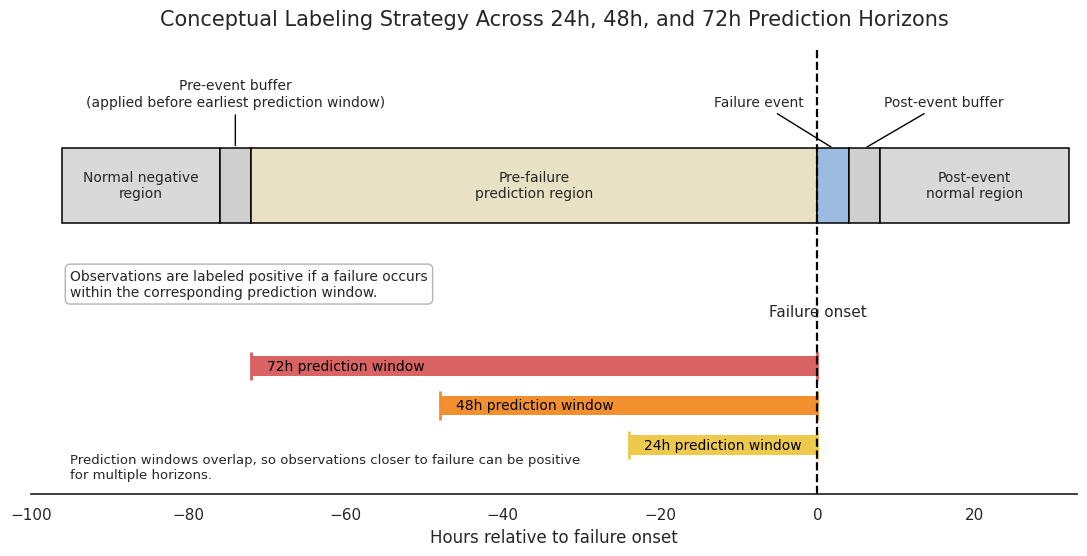

In [39]:
# ------------------------------------------------------------------
# Shared helpers for report figures and tables
# ------------------------------------------------------------------
def prettify_model_name(model_name: str) -> str:
    mapping = {
        "logistic": "Logistic Regression",
        "rf": "Random Forest",
        "random_forest": "Random Forest",
        "xgboost": "XGBoost",
    }
    return mapping.get(str(model_name), str(model_name))


def prettify_experiment_name(experiment_name: str) -> str:
    mapping = {
        "pre_24h": "24h",
        "pre_48h": "48h",
        "pre_72h": "72h",
    }
    return mapping.get(str(experiment_name), str(experiment_name))


def clean_feature_name(feature_name: str) -> str:
    return str(feature_name).replace("_", " ").title()


def save_table_figure(
    df: pd.DataFrame,
    title: str,
    output_path: Path,
    decimals: int = TABLE_DECIMALS,
    index: bool = False,
    figsize: Optional[tuple[float, float]] = None,
) -> None:
    """Render a compact DataFrame as a PNG figure for report insertion."""
    df_to_plot = df.copy()
    numeric_cols = df_to_plot.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df_to_plot[numeric_cols] = df_to_plot[numeric_cols].round(decimals)

    if not index:
        df_to_plot = df_to_plot.reset_index(drop=True)

    n_rows, n_cols = df_to_plot.shape
    if figsize is None:
        figsize = (max(6.5, 1.8 * n_cols), max(1.8, 0.55 * (n_rows + 2)))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    table = ax.table(
        cellText=df_to_plot.values,
        colLabels=df_to_plot.columns,
        loc="center",
        cellLoc="center",
        bbox=[0.01, 0.05, 0.98, 0.72],  # left, bottom, width, height
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.35)
    ax.set_title(title, fontsize=12, pad=2)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved table figure to: {output_path}")


def save_dataframe_csv(df: pd.DataFrame, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    print(f"Saved table data to: {output_path}")


def get_result_row(results_df: pd.DataFrame, model_name: str) -> pd.Series:
    matches = results_df.loc[results_df["model_name"] == model_name]
    if matches.empty:
        raise KeyError(f"Model '{model_name}' was not found in the supplied results.")
    return matches.iloc[0]


report_asset_records: list[dict[str, str]] = []


def has_direct_mapping(mapping_value: Any) -> bool:
    """Return True when a farm has a usable direct mapping for a standardized feature."""
    if mapping_value is None:
        return False
    if isinstance(mapping_value, (list, tuple, set)):
        return any(v not in (None, "") for v in mapping_value)
    return mapping_value != ""


# ------------------------------------------------------------------
# Figure 1: conceptual labeling strategy
# ------------------------------------------------------------------
fig_1_path = REPORT_FIG_DIR / "fig_1_labeling_strategy.png"

pre_buffer_start = -72 - BUFFER_BEFORE_HOURS
event_display_end = FIG_1_EVENT_WINDOW_HOURS
post_buffer_end = event_display_end + BUFFER_AFTER_HOURS

context_segments = [
    (-96, pre_buffer_start, "Normal negative\nregion", "#D9D9D9", True),
    (pre_buffer_start, -72, "", "#CFCFCF", False),
    (-72, 0, "Pre-failure\nprediction region", "#E8E1C4", True),
    (0, event_display_end, "", "#9BBCE0", False),
    (event_display_end, post_buffer_end, "", "#CFCFCF", False),
    (post_buffer_end, 32, "Post-event\nnormal region", "#D9D9D9", True),
]

window_rows = [
    ("72h prediction window", -72, 0, 0.27, "#D95F5F"),
    ("48h prediction window", -48, 0, 0.18, "#F28E2B"),
    ("24h prediction window", -24, 0, 0.09, "#EDC948"),
]

fig, ax = plt.subplots(figsize=(13.5, 5.8))

# Top context timeline
context_y = 0.62
context_height = 0.17
for start, end, label, color, show_label in context_segments:
    ax.add_patch(
        Rectangle(
            (start, context_y),
            end - start,
            context_height,
            facecolor=color,
            edgecolor="black",
            linewidth=1.1,
        )
    )
    if show_label:
        ax.text(
            (start + end) / 2,
            context_y + context_height / 2,
            label,
            ha="center",
            va="center",
            fontsize=10,
        )

# Region annotations above the timeline for narrow segments
annotation_style = dict(arrowstyle="-", linewidth=1.0, color="black")
ax.annotate(
    "Pre-event buffer\n(applied before earliest prediction window)",
    xy=((pre_buffer_start - 72) / 2, context_y + context_height),
    xytext=((pre_buffer_start - 72) / 2, 0.88),
    ha="center",
    va="bottom",
    fontsize=10,
    arrowprops=annotation_style,
)
ax.annotate(
    "Failure event",
    xy=(event_display_end / 2, context_y + context_height),
    xytext=(-1.8, 0.88),
    ha="right",
    va="bottom",
    fontsize=10,
    arrowprops=annotation_style,
)
ax.annotate(
    "Post-event buffer",
    xy=((event_display_end + post_buffer_end) / 2, context_y + context_height),
    xytext=(8.5, 0.88),
    ha="left",
    va="bottom",
    fontsize=10,
    arrowprops=annotation_style,
)

# Bottom model windows
window_height = 0.045
for label, start, end, y, color in window_rows:
    ax.add_patch(
        Rectangle(
            (start, y),
            end - start,
            window_height,
            facecolor=color,
            edgecolor=color,
            linewidth=0,
            alpha=0.98,
        )
    )
    ax.vlines([start, end], y - 0.01, y + window_height + 0.01, colors=color, linewidth=2)
    ax.text(
        start + 2,
        y + window_height / 2,
        label,
        ha="left",
        va="center",
        fontsize=10,
        color="black",
    )

# Failure onset
ax.axvline(0, color="black", linestyle="--", linewidth=1.6)
ax.text(0, 0.40, "Failure onset", ha="center", va="bottom", fontsize=11)

# Explanatory annotations
annotation_box = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#B0B0B0", alpha=0.95)
ax.text(
    -95,
    0.48,
    "Observations are labeled positive if a failure occurs\nwithin the corresponding prediction window.",
    ha="left",
    va="center",
    fontsize=10,
    bbox=annotation_box,
)
ax.text(
    -95,
    0.03,
    "Prediction windows overlap, so observations closer to failure can be positive\nfor multiple horizons.",
    ha="left",
    va="bottom",
    fontsize=9.5,
)

ax.set_xlim(-100, 33)
ax.set_ylim(0, 1.02)
ax.set_yticks([])
ax.set_xlabel("Hours relative to failure onset")
ax.set_title(
    "Conceptual Labeling Strategy Across 24h, 48h, and 72h Prediction Horizons",
    fontsize=15,
    pad=16,
)
ax.spines[["left", "right", "top"]].set_visible(False)

if SAVE_REPORT_FIGURES:
    fig.savefig(fig_1_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 1", "path": str(fig_1_path)})
    print(f"Saved figure to: {fig_1_path}")

plt.show()
plt.close(fig)

## Load the full processed dataset for consolidated analysis

The full master dataset is reused for the report figures, class-balance inspection, and modeling workflow.

In [14]:
master_df = pd.read_parquet(MASTER_DATASET_PATH)
print(f"Master dataset shape: {master_df.shape}")
display(master_df.head(3))


Master dataset shape: (5242948, 46)


,time_stamp,farm_id,asset_id,amb_temp,wind_speed,pitch_angle,active_power,gen_speed,gearbox_oil_temp,transformer_temp,nacelle_temp,hub_temp,yaw_error,vibration_raw,hydraulic_temp,generator_temp,temp_delta_gearbox,temp_trend_24h,rpm_volatility,temp_divergence,power_efficiency,vibration_magnitude,gearbox_oil_temp_delta_6,gearbox_oil_temp_volatility_6,gearbox_oil_temp_delta_24,gearbox_oil_temp_volatility_24,generator_temp_delta_6,generator_temp_volatility_6,generator_temp_delta_24,generator_temp_volatility_24,active_power_delta_6,active_power_volatility_6,active_power_delta_24,active_power_volatility_24,yaw_error_delta_6,yaw_error_volatility_6,yaw_error_delta_24,yaw_error_volatility_24,event_id,event_label,event_start,event_end,state_label,state_name,is_excluded_buffer,target
0,2022-08-04 06:10:00,A,0,22.0,1.7,24.0,-2.560,35.3,41.0,66.333333,30.0,31.0,129.4,22.1,41.0,31.5,19.0,0.0,0.0,-1.0,-0.521067,22.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
1,2022-08-04 06:20:00,A,0,22.0,1.7,24.0,-2.556,0.0,41.0,66.333333,30.0,31.0,133.6,0.0,41.0,31.5,19.0,0.0,0.0,-1.0,-0.520252,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0
2,2022-08-04 06:30:00,A,0,22.0,0.9,24.0,-2.712,2.8,41.0,66.333333,30.0,31.0,167.1,5.8,41.0,31.5,19.0,0.0,0.0,-1.0,-3.720165,5.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,anomaly,2023-08-06 06:10:00,2023-08-20 06:10:00,0,normal,False,0.0


## Figure 2: Cross-Farm Feature Availability and Harmonization Overview

A downstream missingness heatmap turned out to be misleading because the preprocessing pipeline
already harmonizes feature names, fills many derived signals, and hides the actual schema
challenge. For the report, the more meaningful preprocessing visual is a **cross-farm
availability and harmonization matrix**.

This figure shows whether representative standardized modeling features are:

- **Available** from mapped farm-specific raw channels
- **Derived** during harmonization and feature engineering
- **Unavailable** for a given farm

That directly supports the preprocessing narrative around inconsistent raw schemas, uneven
availability, and the need for harmonization before modeling.

,feature,Farm A,Farm B,Farm C
0,Wind Speed,Available,Available,Available
1,Active Power,Available,Available,Available
2,Gen Speed,Available,Available,Available
3,Nacelle Temp,Available,Available,Available
4,Gearbox Oil Temp,Available,Available,Available
5,Generator Temp,Available,Available,Available
6,Hub Temp,Available,Available,Available
7,Hydraulic Temp,Available,Unavailable,Available
8,Vibration Raw,Available,Available,Available
9,Yaw Error,Available,Available,Available


Saved table data to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_2_harmonization_overview.csv


/tmp/ipykernel_3792/1862047688.py:81: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plot_matrix = harmonization_df.set_index("feature").replace(state_to_value)


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_2_harmonization_overview.png


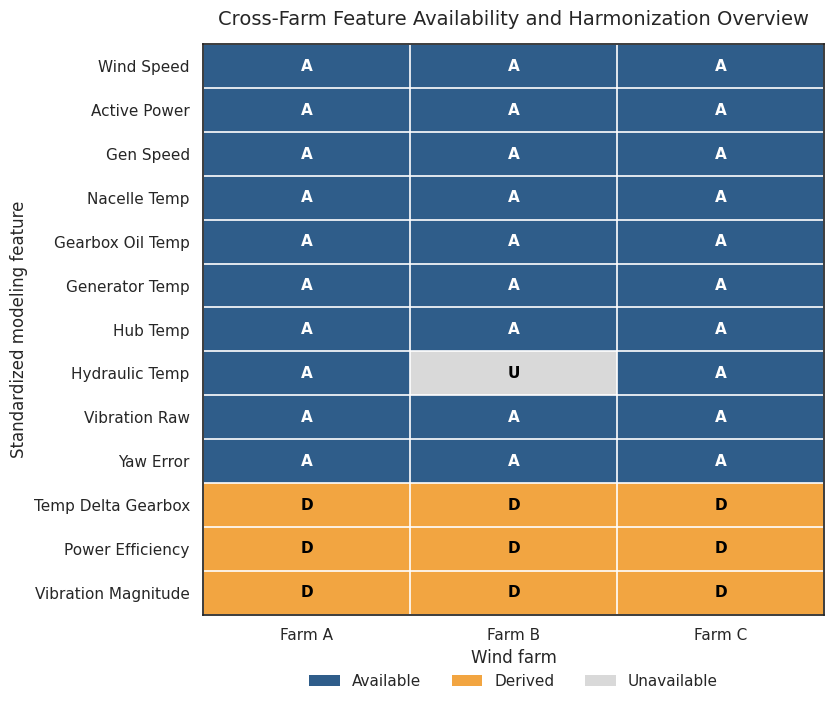

In [32]:
fig_2_path = REPORT_FIG_DIR / "fig_2_harmonization_overview.png"
fig_2_csv_path = REPORT_FIG_DIR / "fig_2_harmonization_overview.csv"

DERIVED_FEATURE_PREREQS = {
    "temp_delta_gearbox": ["gearbox_oil_temp", "amb_temp"],
    "temp_trend_24h": ["gearbox_oil_temp"],
    "rpm_volatility": ["gen_speed"],
    "temp_divergence": ["nacelle_temp", "hub_temp"],
    "power_efficiency": ["wind_speed", "active_power"],
    "vibration_magnitude": ["vibration_raw"],
}

# Keep the report figure focused on the most interpretable features used later in the
# modeling and feature-importance discussion.
HARMONIZATION_FEATURES = [
    "wind_speed",
    "active_power",
    "gen_speed",
    "nacelle_temp",
    "gearbox_oil_temp",
    "generator_temp",
    "hub_temp",
    "hydraulic_temp",
    "vibration_raw",
    "yaw_error",
    "temp_delta_gearbox",
    "power_efficiency",
    "vibration_magnitude",
]


def feature_state_for_farm(feature_name: str, farm_id: str, config: dict[str, Any]) -> str:
    """Classify a standardized feature as Available, Derived, or Unavailable for one farm."""
    farm_sensors = config["farms"][farm_id]["sensors"]

    if feature_name in config.get("standard_features", []):
        return "Available" if has_direct_mapping(farm_sensors.get(feature_name)) else "Unavailable"

    if feature_name in config.get("derived_features", []):
        prereqs = DERIVED_FEATURE_PREREQS.get(feature_name, [])
        if prereqs and all(has_direct_mapping(farm_sensors.get(prereq)) for prereq in prereqs):
            return "Derived"
        return "Unavailable"

    return "Unavailable"


def build_harmonization_overview(
    config: dict[str, Any],
    selected_features: list[str],
) -> pd.DataFrame:
    """Create a feature-by-farm matrix describing harmonization status."""
    records: list[dict[str, str]] = []
    farm_ids = list(config["farms"].keys())

    for feature_name in selected_features:
        feature_label = clean_feature_name(feature_name)
        record = {"feature": feature_label}
        for farm_id in farm_ids:
            record[f"Farm {farm_id}"] = feature_state_for_farm(feature_name, farm_id, config)
        records.append(record)

    return pd.DataFrame(records)


harmonization_df = build_harmonization_overview(
    config=processor.config,
    selected_features=HARMONIZATION_FEATURES,
)

display(harmonization_df)

if SAVE_REPORT_FIGURES:
    save_dataframe_csv(harmonization_df, fig_2_csv_path)
    report_asset_records.append({"asset": "Figure 2 data", "path": str(fig_2_csv_path)})

state_order = ["Unavailable", "Derived", "Available"]
state_to_value = {state: idx for idx, state in enumerate(state_order)}
value_to_code = {"Unavailable": "U", "Derived": "D", "Available": "A"}

plot_matrix = harmonization_df.set_index("feature").replace(state_to_value)
plot_values = plot_matrix.values

fig, ax = plt.subplots(figsize=(8.5, 7.2))
cmap = plt.matplotlib.colors.ListedColormap(["#D9D9D9", "#F2A541", "#2F5D8A"])
ax.imshow(plot_values, aspect="auto", cmap=cmap, vmin=0, vmax=2)

ax.set_xticks(np.arange(plot_matrix.shape[1]))
ax.set_xticklabels(plot_matrix.columns, fontsize=11)
ax.set_yticks(np.arange(plot_matrix.shape[0]))
ax.set_yticklabels(plot_matrix.index, fontsize=11)
ax.set_title("Cross-Farm Feature Availability and Harmonization Overview", fontsize=14, pad=14)
ax.set_xlabel("Wind farm")
ax.set_ylabel("Standardized modeling feature")

# Grid lines for a clean table-like presentation.
ax.set_xticks(np.arange(-0.5, plot_matrix.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_matrix.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

for row_idx in range(plot_values.shape[0]):
    for col_idx in range(plot_values.shape[1]):
        state_name = harmonization_df.iloc[row_idx, col_idx + 1]
        text_color = "white" if state_name == "Available" else "black"
        ax.text(
            col_idx,
            row_idx,
            value_to_code[state_name],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=text_color,
        )

legend_handles = [
    Patch(facecolor="#2F5D8A", edgecolor="none", label="Available"),
    Patch(facecolor="#F2A541", edgecolor="none", label="Derived"),
    Patch(facecolor="#D9D9D9", edgecolor="none", label="Unavailable"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

plt.tight_layout()
if SAVE_REPORT_FIGURES:
    plt.savefig(fig_2_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 2", "path": str(fig_2_path)})
    print(f"Saved figure to: {fig_2_path}")
plt.show()
plt.close()

## Optional preprocessing sanity check: Canonical State Distribution

This diagnostic is kept for notebook transparency, but it is no longer computed on a tiny
sample. Instead, it summarizes the **full processed dataset** so the canonical state logic
can be checked directly, including whether excluded-buffer rows are present after
preprocessing.

In [33]:
state_order = [
    "normal",
    "excluded_buffer",
    "pre_48_72h",
    "pre_24_48h",
    "pre_0_24h",
    "event_occurring",
]

if "state_name" in master_df.columns:
    state_counts = (
        master_df["state_name"]
        .astype(str)
        .value_counts()
        .reindex(state_order, fill_value=0)
        .rename_axis("state_name")
        .reset_index(name="count")
    )
    state_counts["percent"] = state_counts["count"] / state_counts["count"].sum()

    display(state_counts)

    plt.figure(figsize=(9.5, 4.8))
    plt.bar(state_counts["state_name"], state_counts["count"])
    plt.title("Canonical State Distribution in the Full Processed Dataset")
    plt.xlabel("Canonical state")
    plt.ylabel("Row count")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("The processed dataset does not contain 'state_name', so this sanity check was skipped.")

NameError: name 'master_df' is not defined

## Modeling Helpers

The following utilities either load the most recent saved experiment artifacts or execute the full experiment directly from the processed dataset. This is the key mechanism that keeps the notebook practical.


In [17]:
def find_latest_run_dir(experiment_name: str, artifact_root: Path) -> Optional[Path]:
    """Return the newest saved artifact directory for an experiment, if one exists."""
    experiment_dir = artifact_root / experiment_name
    if not experiment_dir.exists():
        return None

    run_dirs = [p for p in experiment_dir.iterdir() if p.is_dir()]
    if not run_dirs:
        return None

    return max(run_dirs, key=lambda p: p.stat().st_mtime)


def load_saved_experiment_bundle(experiment_name: str, artifact_root: Path) -> Optional[dict[str, Any]]:
    """Load saved CSV/JSON artifacts for the newest experiment run if they exist."""
    run_dir = find_latest_run_dir(experiment_name, artifact_root)
    if run_dir is None:
        return None

    results_path = run_dir / "model_comparison_summary.csv"
    threshold_path = run_dir / "threshold_sweep.csv"
    importance_path = run_dir / "feature_importance.csv"
    metadata_path = run_dir / "run_metadata.json"
    summary_metrics_path = run_dir / "summary_metrics.json"

    core_paths = [results_path, threshold_path, importance_path, metadata_path, summary_metrics_path]
    if not all(path.exists() for path in core_paths):
        return None

    results_df = load_dataframe_artifact(results_path)
    threshold_df = load_dataframe_artifact(threshold_path)
    importance_df = load_dataframe_artifact(importance_path)
    run_metadata = load_json_artifact(metadata_path)
    summary_metrics = load_json_artifact(summary_metrics_path)

    best_model_name = summary_metrics.get("best_model_name")
    best_threshold = summary_metrics.get("best_threshold")

    best_row = None
    if "model_name" in results_df.columns and best_model_name in set(results_df["model_name"]):
        best_row = results_df.loc[results_df["model_name"] == best_model_name].iloc[0].to_dict()
    elif not results_df.empty:
        best_row = results_df.iloc[0].to_dict()

    return {
        "experiment_name": experiment_name,
        "source": "saved_artifact",
        "run_dir": run_dir,
        "results_df": results_df,
        "threshold_df": threshold_df,
        "importance_df": importance_df,
        "run_metadata": run_metadata,
        "summary_metrics": summary_metrics,
        "best_model_name": best_model_name,
        "best_threshold": best_threshold,
        "best_row": best_row,
        "train_df": None,
        "val_df": None,
        "test_df": None,
        "feature_summary": run_metadata.get("feature_selection"),
        "detailed_results": None,
    }


def build_experiment_dataset(df: pd.DataFrame, experiment_config: dict[str, Any]) -> pd.DataFrame:
    """Create the experiment-specific binary target and drop excluded-buffer rows."""
    df_exp = WindFarmSplitter.create_binary_target_from_state(
        df=df.copy(),
        positive_states=experiment_config["positive_states"],
    )
    df_exp = df_exp[df_exp["target"].notna()].copy()
    df_exp["target"] = df_exp["target"].astype(int)
    return df_exp


def split_experiment_dataset(
    modeling_df: pd.DataFrame,
    split_method: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Route to the appropriate splitter method."""
    splitter = WindFarmSplitter(random_state=random_state)

    if split_method in {"event_chronological", "event_level_time"}:
        return splitter.get_event_level_time_split(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )
    if split_method in {"group_time", "grouped_time_by_turbine"}:
        return splitter.get_grouped_time_split_by_turbine(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )
    if split_method in {"global_time", "chronological"}:
        return splitter.get_global_time_split(
            modeling_df,
            train_size=train_size,
            val_size=val_size,
            test_size=test_size,
        )

    raise ValueError(f"Unsupported split_method: {split_method}")


def run_experiment_fresh(
    master_df: pd.DataFrame,
    experiment_name: str,
    artifact_root: Path,
    model_names_override: Optional[list[str]] = None,
    numeric_only: bool = True,
    feature_subset: Optional[str] = None,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42,
    save_outputs: bool = False,
) -> dict[str, Any]:
    """Run a modeling experiment from scratch using the reusable project modules."""
    experiment = get_experiment_config(experiment_name)
    modeling_df = build_experiment_dataset(master_df, experiment)

    train_df, val_df, test_df = split_experiment_dataset(
        modeling_df=modeling_df,
        split_method=experiment["split_method"],
        train_size=train_size,
        val_size=val_size,
        test_size=test_size,
        random_state=random_state,
    )

    feature_summary = summarize_feature_selection(
        train_df,
        numeric_only=numeric_only,
        feature_subset=feature_subset,
    )
    feature_names = feature_summary["selected_features"]
    validate_no_leakage_columns_in_features(feature_names)

    X_train = build_feature_matrix(train_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_train = train_df["target"].copy()

    X_val = build_feature_matrix(val_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_val = val_df["target"].copy()

    X_test = build_feature_matrix(test_df, numeric_only=numeric_only, feature_subset=feature_subset)
    y_test = test_df["target"].copy()

    model_names = model_names_override or list(experiment["models"])
    if not HAS_XGBOOST:
        model_names = [name for name in model_names if name != "xgboost"]

    tournament_rows = []
    detailed_results: dict[str, Any] = {}

    for model_name in model_names:
        model_config = get_model_config(model_name)

        trainer = WindFaultTrainer(
            model_type=model_config["model_type"],
            params=model_config["params"],
            random_state=random_state,
        )

        tuned_threshold = trainer.fit_and_tune(
            X_train=X_train,
            y_train=y_train,
            X_val=X_val,
            y_val=y_val,
            optimize_for=experiment["optimize_for"],
        )

        train_metrics = trainer.evaluate_detailed(X_train, y_train)
        val_metrics = trainer.evaluate_detailed(X_val, y_val)
        test_metrics = trainer.evaluate_detailed(X_test, y_test)

        tournament_rows.append(
            {
                "model_name": model_name,
                "model_type": model_config["model_type"],
                "threshold": tuned_threshold,
                "train_precision": train_metrics["precision"],
                "train_recall": train_metrics["recall"],
                "train_f1": train_metrics["f1"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
                "test_roc_auc": test_metrics["roc_auc"],
                "test_pr_auc": test_metrics["pr_auc"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_specificity": test_metrics["specificity"],
            }
        )

        detailed_results[model_name] = {
            "trainer": trainer,
            "train_metrics": train_metrics,
            "val_metrics": val_metrics,
            "test_metrics": test_metrics,
            "model_config": model_config,
        }

        gc.collect()

    results_df = (
        pd.DataFrame(tournament_rows)
        .sort_values(
            by=["test_f1", "test_recall", "test_precision"],
            ascending=[False, False, False],
        )
        .reset_index(drop=True)
    )

    if results_df.empty:
        raise RuntimeError(
            f"No model results were produced for experiment '{experiment_name}'. "
            "Check model availability and configuration."
        )

    best_model_name = results_df.iloc[0]["model_name"]
    best_bundle = detailed_results[best_model_name]
    best_trainer = best_bundle["trainer"]
    best_test_metrics = best_bundle["test_metrics"]

    importance_df = best_trainer.get_feature_importance(feature_names).copy()
    threshold_df = build_threshold_sweep_table(
        y_true=y_test,
        y_prob=best_trainer.predict_proba(X_test),
    )

    run_dir = None
    if save_outputs:
        run_dir = ensure_run_output_dir(
            base_output_dir=artifact_root,
            experiment_name=experiment_name,
        )

        metadata = {
            "experiment_name": experiment_name,
            "experiment_config": experiment,
            "data_path": str(MASTER_DATASET_PATH),
            "feature_selection": feature_summary,
            "split_sizes": {
                "train": len(train_df),
                "val": len(val_df),
                "test": len(test_df),
            },
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "best_test_metrics": {
                "precision": float(best_test_metrics["precision"]),
                "recall": float(best_test_metrics["recall"]),
                "f1": float(best_test_metrics["f1"]),
                "roc_auc": float(best_test_metrics["roc_auc"]),
                "pr_auc": float(best_test_metrics["pr_auc"]),
                "balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
                "specificity": float(best_test_metrics["specificity"]),
            },
        }

        summary_metrics = {
            "experiment_name": experiment_name,
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "test_metrics": metadata["best_test_metrics"],
        }

        save_dataframe_artifact(results_df, run_dir / "model_comparison_summary.csv")
        save_feature_importance(importance_df, run_dir)
        save_threshold_sweep(threshold_df, run_dir)
        save_run_metadata(metadata, run_dir)
        save_model_metrics(summary_metrics, run_dir)

    return {
        "experiment_name": experiment_name,
        "source": "fresh_run",
        "run_dir": run_dir,
        "results_df": results_df,
        "threshold_df": threshold_df,
        "importance_df": importance_df,
        "run_metadata": {
            "experiment_name": experiment_name,
            "experiment_config": experiment,
            "feature_selection": feature_summary,
            "split_sizes": {
                "train": len(train_df),
                "val": len(val_df),
                "test": len(test_df),
            },
        },
        "summary_metrics": {
            "experiment_name": experiment_name,
            "best_model_name": best_model_name,
            "best_threshold": float(best_trainer.best_threshold),
            "test_metrics": {
                "precision": float(best_test_metrics["precision"]),
                "recall": float(best_test_metrics["recall"]),
                "f1": float(best_test_metrics["f1"]),
                "roc_auc": float(best_test_metrics["roc_auc"]),
                "pr_auc": float(best_test_metrics["pr_auc"]),
                "balanced_accuracy": float(best_test_metrics["balanced_accuracy"]),
                "specificity": float(best_test_metrics["specificity"]),
            },
        },
        "best_model_name": best_model_name,
        "best_threshold": float(best_trainer.best_threshold),
        "best_row": results_df.iloc[0].to_dict(),
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "feature_summary": feature_summary,
        "detailed_results": detailed_results,
    }


def get_experiment_bundle(
    master_df: pd.DataFrame,
    experiment_name: str,
    artifact_root: Path,
    reuse_saved_model_artifacts: bool = True,
    save_fresh_modeling_artifacts: bool = False,
) -> dict[str, Any]:
    """Load a saved experiment bundle if available, otherwise run it fresh."""
    if reuse_saved_model_artifacts:
        saved_bundle = load_saved_experiment_bundle(experiment_name, artifact_root)
        if saved_bundle is not None:
            return saved_bundle

    return run_experiment_fresh(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=artifact_root,
        model_names_override=MODEL_NAMES_OVERRIDE,
        numeric_only=NUMERIC_ONLY,
        feature_subset=FEATURE_SUBSET,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        save_outputs=SAVE_FRESH_MODELING_ARTIFACTS,
    )


## Run or reuse the three horizon experiments

Each experiment either loads the most recent saved artifact bundle or executes the modeling workflow directly. This produces a clean comparison between prediction windows without rewriting the core project logic.


In [18]:
experiment_bundles: dict[str, dict[str, Any]] = {}

for experiment_name in EXPERIMENT_NAMES:
    print(f"\n=== {experiment_name} ===")
    bundle = get_experiment_bundle(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=ARTIFACT_ROOT,
        reuse_saved_model_artifacts=REUSE_SAVED_MODEL_ARTIFACTS,
        save_fresh_modeling_artifacts=SAVE_FRESH_MODELING_ARTIFACTS,
    )
    experiment_bundles[experiment_name] = bundle

    print(f"Source: {bundle['source']}")
    if bundle.get("run_dir") is not None:
        print(f"Run directory: {bundle['run_dir']}")
    display(bundle["results_df"])


2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/model_comparison_summary.csv | shape=(3, 16)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/threshold_sweep.csv | shape=(55, 16)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/feature_importance.csv | shape=(35, 2)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded JSON artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310/run_metadata.json | keys=['best_model_name', 'best_test_metrics', 'best_threshol


=== pre_24h ===
Source: saved_artifact
Run directory: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_24h/pre_24h_20260321_164310


,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,xgboost,xgboost,0.78,0.325224,0.675571,0.439075,0.073635,0.224445,0.110890,0.124795,0.131682,0.128146,0.392988,0.042840,0.551873,0.972064
1,rf,rf,0.62,0.189889,0.782062,0.305581,0.042894,0.336180,0.076081,0.084788,0.144912,0.106981,0.406848,0.034602,0.548797,0.952683
2,logistic,logistic,0.26,0.029214,0.953789,0.056692,0.012970,0.816541,0.025535,0.026942,0.700326,0.051887,0.464775,0.053580,0.467591,0.234856



=== pre_48h ===


2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_48h/pre_48h_20260321_162321/model_comparison_summary.csv | shape=(3, 16)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_48h/pre_48h_20260321_162321/threshold_sweep.csv | shape=(55, 16)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_48h/pre_48h_20260321_162321/feature_importance.csv | shape=(35, 2)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded JSON artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_48h/pre_48h_20260321_162321/run_metadata.json | keys=['best_model_name', 'best_test_metrics', 'best_threshol

...

2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/model_comparison_summary.csv | shape=(3, 16)



=== pre_72h ===


2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/threshold_sweep.csv | shape=(55, 16)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded DataFrame artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/feature_importance.csv | shape=(35, 2)
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded JSON artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937/run_metadata.json | keys=['best_model_name', 'best_test_metrics', 'best_threshold', 'data_path', 'experiment_config', 'experiment_name', 'feature_selection', 'split_sizes']
2026-04-14 17:11:42 | INFO | wtfd.models.artifacts | Loaded JSON artifact from /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifact

Source: saved_artifact
Run directory: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/artifacts/modeling/pre_72h/pre_72h_20260321_144937


,model_name,model_type,threshold,train_precision,train_recall,train_f1,val_precision,val_recall,val_f1,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_balanced_accuracy,test_specificity
0,xgboost,xgboost,0.78,0.342590,0.646541,0.447865,0.094543,0.261569,0.138887,0.127120,0.135283,0.131075,0.438779,0.049057,0.551867,0.968451
1,logistic,logistic,0.28,0.032228,0.941075,0.062321,0.015841,0.827869,0.031087,0.030652,0.703459,0.058744,0.465910,0.058220,0.473951,0.244442
2,rf,rf,0.76,0.354988,0.479558,0.407976,0.087788,0.151484,0.111158,0.064908,0.031721,0.042615,0.435072,0.035167,0.508100,0.984479


## Figure 3: Class Imbalance Distribution

The results section begins with the modeling class balance for the representative 72-hour horizon. This uses the experiment-specific binary target after excluded rows have been dropped.

In [34]:
report_experiment_config = get_experiment_config(REPORT_EXPERIMENT_NAME)
report_modeling_df = build_experiment_dataset(master_df, report_experiment_config).copy()

class_balance_df = (
    report_modeling_df["target"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("target")
    .reset_index(name="count")
)
class_balance_df["class_name"] = class_balance_df["target"].map({0: "Non-failure", 1: "Failure"})
class_balance_df["percent"] = class_balance_df["count"] / class_balance_df["count"].sum()

display(class_balance_df[["class_name", "count", "percent"]])

fig_3_path = REPORT_FIG_DIR / "fig_3_class_imbalance_distribution.png"

plt.figure(figsize=(7.5, 5))
bars = plt.bar(class_balance_df["class_name"], class_balance_df["percent"])
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title(f"Class Distribution for {prettify_experiment_name(REPORT_EXPERIMENT_NAME)} Modeling Dataset")
plt.xlabel("Class")
plt.ylabel("Proportion of modeling rows")
plt.ylim(1.1)

y_offset = max(class_balance_df["percent"]) * 0.015
for bar, count in zip(bars, class_balance_df["count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + y_offset,
        f"{int(count):,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
if SAVE_REPORT_FIGURES:
    plt.savefig(fig_3_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 3", "path": str(fig_3_path)})
    print(f"Saved figure to: {fig_3_path}")
plt.show()
plt.close()

2026-04-14 21:20:53 | INFO | wtfd.models.experiments | Retrieved experiment config 'pre_72h' | models=['logistic', 'rf', 'xgboost'] | optimize_for=f1 | split_method=event_chronological


NameError: name 'master_df' is not defined

## Figure 4: Model Performance Comparison Table

The next table compares the three candidate models for the representative 72-hour prediction horizon using holdout test-set precision, recall, and F1 score.

,Model,Precision,Recall,F1
0,XGBoost,0.127120,0.135283,0.131075
1,Logistic Regression,0.030652,0.703459,0.058744
2,Random Forest,0.064908,0.031721,0.042615


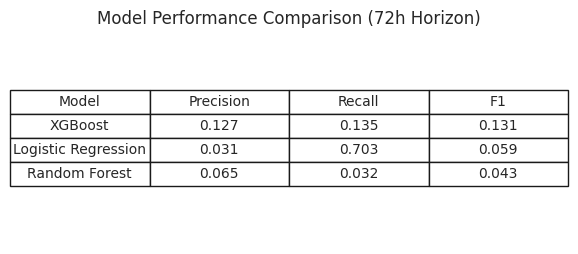

Saved table figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_4_model_performance_comparison_table.png
Saved table data to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_4_model_performance_comparison_table.csv


In [36]:
results_72h_df = experiment_bundles[REPORT_EXPERIMENT_NAME]["results_df"].copy()

model_table_df = (
    results_72h_df.loc[:, ["model_name", "test_precision", "test_recall", "test_f1"]]
    .rename(
        columns={
            "model_name": "Model",
            "test_precision": "Precision",
            "test_recall": "Recall",
            "test_f1": "F1",
        }
    )
)
model_table_df["Model"] = model_table_df["Model"].map(prettify_model_name)
model_table_df = model_table_df.sort_values("F1", ascending=False).reset_index(drop=True)

display(model_table_df)

fig_4_path = REPORT_FIG_DIR / "fig_4_model_performance_comparison_table.png"
fig_4_csv_path = REPORT_FIG_DIR / "fig_4_model_performance_comparison_table.csv"

if SAVE_REPORT_FIGURES:
    save_table_figure(
        model_table_df,
        title=f"Model Performance Comparison ({prettify_experiment_name(REPORT_EXPERIMENT_NAME)} Horizon)",
        output_path=fig_4_path,
        index=False,
    )
    save_dataframe_csv(model_table_df, fig_4_csv_path)
    report_asset_records.append({"asset": "Figure 4", "path": str(fig_4_path)})
    report_asset_records.append({"asset": "Figure 4 data", "path": str(fig_4_csv_path)})

## Figure 5: Prediction Window Comparison Table

This table isolates XGBoost so the report can compare precision, recall, and F1 score across the 24-hour, 48-hour, and 72-hour horizons directly.

,Window,Precision,Recall,F1
0,24h,0.124795,0.131682,0.128146
1,48h,0.127321,0.105902,0.115628
2,72h,0.127120,0.135283,0.131075


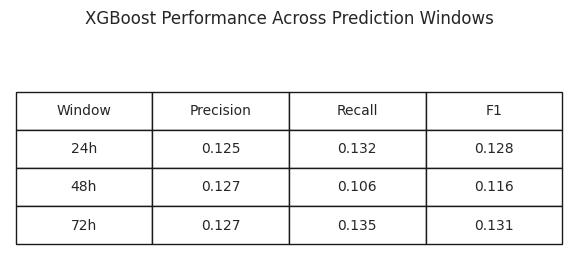

Saved table figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_5_prediction_window_comparison_table.png
Saved table data to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_5_prediction_window_comparison_table.csv


In [38]:
xgb_rows = []

for experiment_name, bundle in experiment_bundles.items():
    results_df = bundle["results_df"].copy()
    if REPORT_MODEL_NAME not in set(results_df["model_name"]):
        continue

    row = get_result_row(results_df, REPORT_MODEL_NAME)
    xgb_rows.append(
        {
            "Window": prettify_experiment_name(experiment_name),
            "Precision": row["test_precision"],
            "Recall": row["test_recall"],
            "F1": row["test_f1"],
        }
    )

xgb_window_table_df = pd.DataFrame(xgb_rows).sort_values("Window").reset_index(drop=True)
display(xgb_window_table_df)

fig_5_path = REPORT_FIG_DIR / "fig_5_prediction_window_comparison_table.png"
fig_5_csv_path = REPORT_FIG_DIR / "fig_5_prediction_window_comparison_table.csv"

if SAVE_REPORT_FIGURES:
    save_table_figure(
        xgb_window_table_df,
        title="XGBoost Performance Across Prediction Windows",
        output_path=fig_5_path,
        index=False,
    )
    save_dataframe_csv(xgb_window_table_df, fig_5_csv_path)
    report_asset_records.append({"asset": "Figure 5", "path": str(fig_5_path)})
    report_asset_records.append({"asset": "Figure 5 data", "path": str(fig_5_csv_path)})

## Prepare a lightweight fresh diagnostic run for report-specific plots

Saved experiment artifacts are sufficient for most comparisons, but the report also needs a **validation-set threshold sweep** and a **predicted-probability timeline**. Those require row-level predictions, so the notebook trains a single fresh XGBoost model for the representative 72-hour horizon only when cached report diagnostics are not already available.

In [22]:
def get_report_diagnostics(
    master_df: pd.DataFrame,
    experiment_name: str = REPORT_EXPERIMENT_NAME,
    model_name: str = REPORT_MODEL_NAME,
    force_rebuild: bool = FORCE_REBUILD_REPORT_DIAGNOSTICS,
) -> dict[str, Any]:
    """Load cached report diagnostics or build them with one fresh model run."""
    diag_dir = REPORT_DIAGNOSTICS_DIR / experiment_name / model_name
    diag_dir.mkdir(parents=True, exist_ok=True)

    predictions_path = diag_dir / "test_predictions.parquet"
    validation_threshold_path = diag_dir / "validation_threshold_sweep.csv"
    feature_importance_path = diag_dir / "feature_importance.csv"
    metadata_path = diag_dir / "diagnostic_metadata.json"

    if (
        not force_rebuild
        and predictions_path.exists()
        and validation_threshold_path.exists()
        and feature_importance_path.exists()
        and metadata_path.exists()
    ):
        return {
            "source": "cached_report_diagnostics",
            "test_predictions_df": pd.read_parquet(predictions_path),
            "validation_threshold_df": pd.read_csv(validation_threshold_path),
            "feature_importance_df": pd.read_csv(feature_importance_path),
            "metadata": json.loads(metadata_path.read_text()),
        }

    fresh_bundle = run_experiment_fresh(
        master_df=master_df,
        experiment_name=experiment_name,
        artifact_root=ARTIFACT_ROOT,
        model_names_override=[model_name],
        numeric_only=NUMERIC_ONLY,
        feature_subset=FEATURE_SUBSET,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        save_outputs=False,
    )

    trainer = fresh_bundle["detailed_results"][model_name]["trainer"]
    val_df = fresh_bundle["val_df"].copy()
    test_df = fresh_bundle["test_df"].copy()

    X_val = build_feature_matrix(val_df, numeric_only=NUMERIC_ONLY, feature_subset=FEATURE_SUBSET)
    y_val = val_df["target"].copy()

    X_test = build_feature_matrix(test_df, numeric_only=NUMERIC_ONLY, feature_subset=FEATURE_SUBSET)

    validation_threshold_df = build_threshold_sweep_table(
        y_true=y_val,
        y_prob=trainer.predict_proba(X_val),
    )

    test_predictions_df = test_df.copy()
    test_predictions_df["predicted_probability"] = trainer.predict_proba(X_test)
    test_predictions_df["predicted_label"] = (
        test_predictions_df["predicted_probability"] >= float(trainer.best_threshold)
    ).astype(int)

    feature_importance_df = trainer.get_feature_importance(
        fresh_bundle["feature_summary"]["selected_features"]
    ).copy()

    metadata = {
        "experiment_name": experiment_name,
        "model_name": model_name,
        "best_threshold": float(trainer.best_threshold),
        "source": "fresh_report_run",
        "n_val_rows": int(len(val_df)),
        "n_test_rows": int(len(test_df)),
    }

    test_predictions_df.to_parquet(predictions_path, index=False)
    validation_threshold_df.to_csv(validation_threshold_path, index=False)
    feature_importance_df.to_csv(feature_importance_path, index=False)
    metadata_path.write_text(json.dumps(metadata, indent=2))

    return {
        "source": "fresh_report_run",
        "test_predictions_df": test_predictions_df,
        "validation_threshold_df": validation_threshold_df,
        "feature_importance_df": feature_importance_df,
        "metadata": metadata,
    }


report_diag = get_report_diagnostics(master_df=master_df)
print("Report diagnostic source:", report_diag["source"])
display(pd.DataFrame([report_diag["metadata"]]))

Report diagnostic source: cached_report_diagnostics


,experiment_name,model_name,best_threshold,source,n_val_rows,n_test_rows
0,pre_72h,xgboost,0.82,fresh_report_run,762179,826342


## Figure 6: Threshold Sweep Curve

For the report, this plot is generated from the **validation set**, which is the correct split for threshold selection. The tuned threshold is highlighted to show why the operational cutoff is not the default value of 0.5.

,threshold,precision,recall,f1,balanced_accuracy,specificity,false_positive_rate,false_negative_rate,tp,fp,tn,fn,support_positive,support_negative,roc_auc,pr_auc
44,0.82,0.046028,0.287037,0.079335,0.635065,0.983093,0.016907,0.712963,620,12850,747169,1540,2160,760019,0.801253,0.024725
45,0.84,0.047192,0.248611,0.079326,0.617173,0.985735,0.014265,0.751389,537,10842,749177,1623,2160,760019,0.801253,0.024725
42,0.78,0.043905,0.357870,0.078215,0.667861,0.977852,0.022148,0.642130,773,16833,743186,1387,2160,760019,0.801253,0.024725
43,0.80,0.044537,0.318519,0.078146,0.649549,0.980579,0.019421,0.681481,688,14760,745259,1472,2160,760019,0.801253,0.024725
41,0.76,0.042256,0.385648,0.076167,0.680403,0.975159,0.024841,0.614352,833,18880,741139,1327,2160,760019,0.801253,0.024725
40,0.75,0.041477,0.400000,0.075160,0.686864,0.973728,0.026272,0.600000,864,19967,740052,1296,2160,760019,0.801253,0.024725
46,0.86,0.045699,0.193056,0.073903,0.590799,0.988542,0.011458,0.806944,417,8708,751311,1743,2160,760019,0.801253,0.024725
39,0.74,0.040044,0.408333,0.072935,0.690256,0.972180,0.027820,0.591667,882,21144,738875,1278,2160,760019,0.801253,0.024725
38,0.72,0.037802,0.426389,0.069447,0.697772,0.969155,0.030845,0.573611,921,23443,736576,1239,2160,760019,0.801253,0.024725
37,0.70,0.035721,0.442130,0.066101,0.704105,0.966080,0.033920,0.557870,955,25780,734239,1205,2160,760019,0.801253,0.024725


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_6_threshold_sweep_curve.png


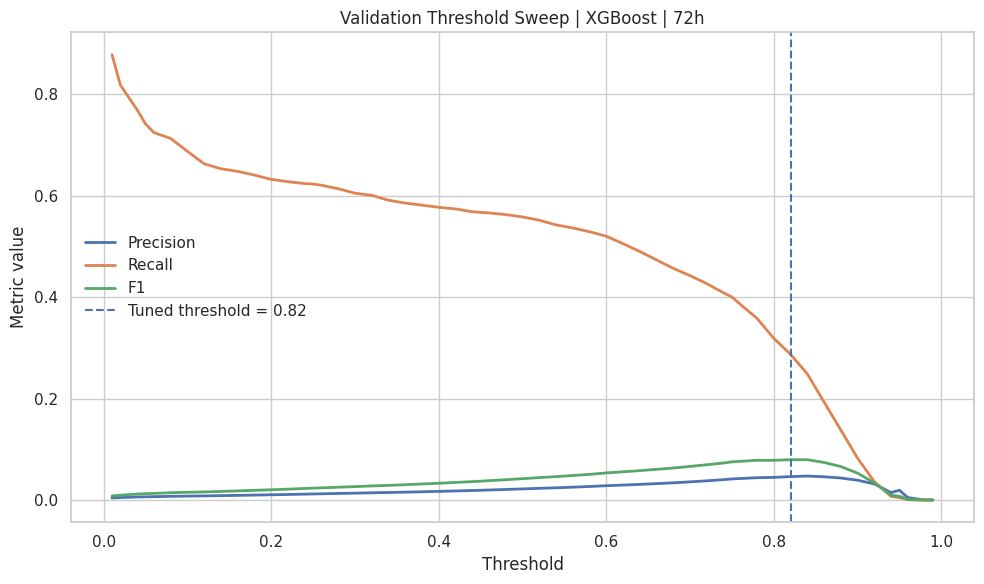

In [23]:
validation_threshold_df = report_diag["validation_threshold_df"].copy()
best_threshold = report_diag["metadata"]["best_threshold"]

display(
    validation_threshold_df.sort_values(
        by=["f1", "recall", "precision"],
        ascending=[False, False, False],
    ).head(15)
)

fig_6_path = REPORT_FIG_DIR / "fig_6_threshold_sweep_curve.png"

plt.figure(figsize=(10, 6))
plt.plot(validation_threshold_df["threshold"], validation_threshold_df["precision"], label="Precision", linewidth=2)
plt.plot(validation_threshold_df["threshold"], validation_threshold_df["recall"], label="Recall", linewidth=2)
plt.plot(validation_threshold_df["threshold"], validation_threshold_df["f1"], label="F1", linewidth=2)
plt.axvline(best_threshold, linestyle="--", linewidth=1.5, label=f"Tuned threshold = {best_threshold:.2f}")
plt.title(f"Validation Threshold Sweep | {prettify_model_name(REPORT_MODEL_NAME)} | {prettify_experiment_name(REPORT_EXPERIMENT_NAME)}")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend(frameon=False)
plt.tight_layout()
if SAVE_REPORT_FIGURES:
    plt.savefig(fig_6_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 6", "path": str(fig_6_path)})
    print(f"Saved figure to: {fig_6_path}")
plt.show()
plt.close()

## Figure 7: Temporal Prediction Timeline

This figure uses one representative event from the test set and plots the tuned-model
predicted probability over time around failure onset. The event selection rule prefers
cases with actual positive-labeled rows and then stronger sustained model response, which
is more defensible than choosing the single largest probability spike.

,farm_id,asset_id,event_id,event_label,event_start,n_rows,n_positive,max_probability,mean_probability
0,A,0,26,anomaly,2023-10-12 10:20:00,53702,432,0.988163,0.250586
1,C,16,30,anomaly,2023-12-15 00:00:00,56111,432,0.813950,0.112180
2,C,53,16,anomaly,2023-12-23 00:00:00,53568,432,0.996661,0.101560
3,C,52,39,anomaly,2023-10-19 13:00:00,53727,432,0.986235,0.099228
4,C,43,11,anomaly,2023-10-17 12:30:00,56437,432,0.992674,0.086360
5,C,21,47,anomaly,2023-12-22 15:00:00,53993,432,0.747753,0.071594
6,C,38,81,anomaly,2023-11-16 01:30:00,53932,432,0.880083,0.039947
7,C,50,55,anomaly,2023-10-29 11:30:00,55753,432,0.313020,0.006795
8,C,23,70,anomaly,2023-11-10 14:00:00,56038,432,0.289517,0.006764
9,B,6,53,anomaly,2023-12-26 16:40:00,58607,431,0.936843,0.060949


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_7_temporal_prediction_timeline.png


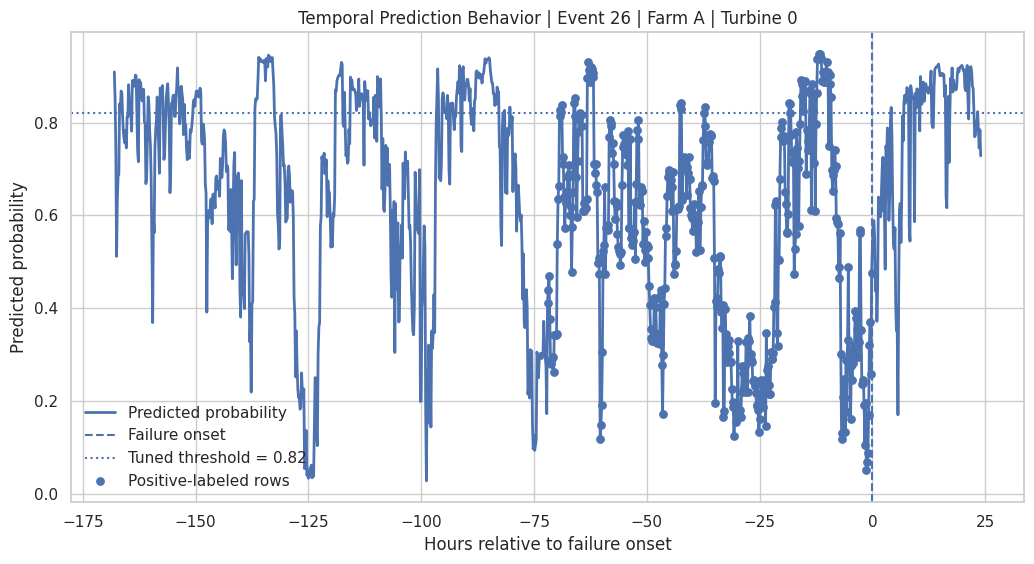

,time_stamp,hours_from_event_start,predicted_probability,target,state_name
106343,2023-10-05 10:20:00,-168.000000,0.909085,0,normal
106344,2023-10-05 10:30:00,-167.833333,0.853167,0,normal
106345,2023-10-05 10:40:00,-167.666667,0.747235,0,normal
106346,2023-10-05 10:50:00,-167.500000,0.511619,0,normal
106347,2023-10-05 11:00:00,-167.333333,0.633300,0,normal
106348,2023-10-05 11:10:00,-167.166667,0.683764,0,normal
106349,2023-10-05 11:20:00,-167.000000,0.688391,0,normal
106350,2023-10-05 11:30:00,-166.833333,0.840331,0,normal
106351,2023-10-05 11:40:00,-166.666667,0.826274,0,normal
106352,2023-10-05 11:50:00,-166.500000,0.867860,0,normal


In [24]:
timeline_predictions_df = report_diag["test_predictions_df"].copy()

for dt_col in ["time_stamp", "event_start", "event_end"]:
    if dt_col in timeline_predictions_df.columns:
        timeline_predictions_df[dt_col] = pd.to_datetime(timeline_predictions_df[dt_col], errors="coerce")

group_cols = [c for c in ["farm_id", "asset_id", "event_id", "event_label", "event_start"] if c in timeline_predictions_df.columns]

if not group_cols:
    raise KeyError(
        "The prediction timeline requires event metadata columns such as "
        "'farm_id', 'asset_id', 'event_id', and 'event_start'."
    )

event_summary_df = (
    timeline_predictions_df.dropna(subset=["event_start"])
    .groupby(group_cols, dropna=False)
    .agg(
        n_rows=("predicted_probability", "size"),
        n_positive=("target", "sum"),
        max_probability=("predicted_probability", "max"),
        mean_probability=("predicted_probability", "mean"),
    )
    .reset_index()
)

positive_event_summary_df = event_summary_df.loc[event_summary_df["n_positive"] > 0].copy()
if positive_event_summary_df.empty:
    positive_event_summary_df = event_summary_df.copy()

# Choose a representative event with actual positive-labeled rows, then prefer
# stronger model response within that subset. This is more defensible than
# selecting solely on the single highest peak probability.
positive_event_summary_df = positive_event_summary_df.sort_values(
    by=["n_positive", "mean_probability", "max_probability", "event_start"],
    ascending=[False, False, False, True],
).reset_index(drop=True)

display(positive_event_summary_df.head(10))

selected_event = positive_event_summary_df.iloc[0].to_dict()

mask = pd.Series(True, index=timeline_predictions_df.index)
for col in group_cols:
    value = selected_event[col]
    if pd.isna(value):
        mask &= timeline_predictions_df[col].isna()
    else:
        mask &= timeline_predictions_df[col] == value

selected_timeline_df = timeline_predictions_df.loc[mask].copy().sort_values("time_stamp")

selected_event_start = pd.to_datetime(selected_event["event_start"])
selected_timeline_df["hours_from_event_start"] = (
    (selected_timeline_df["time_stamp"] - selected_event_start).dt.total_seconds() / 3600.0
)

selected_timeline_df = selected_timeline_df[
    (selected_timeline_df["hours_from_event_start"] >= -TIMELINE_HOURS_BEFORE)
    & (selected_timeline_df["hours_from_event_start"] <= TIMELINE_HOURS_AFTER)
].copy()

fig_7_path = REPORT_FIG_DIR / "fig_7_temporal_prediction_timeline.png"

plt.figure(figsize=(10.5, 5.8))
plt.plot(
    selected_timeline_df["hours_from_event_start"],
    selected_timeline_df["predicted_probability"],
    linewidth=2,
    label="Predicted probability",
)
plt.axvline(0, linestyle="--", linewidth=1.5, label="Failure onset")
plt.axhline(best_threshold, linestyle=":", linewidth=1.5, label=f"Tuned threshold = {best_threshold:.2f}")

positive_rows_df = selected_timeline_df.loc[selected_timeline_df["target"] == 1]
if not positive_rows_df.empty:
    plt.scatter(
        positive_rows_df["hours_from_event_start"],
        positive_rows_df["predicted_probability"],
        s=28,
        label="Positive-labeled rows",
    )

event_label_text = selected_event.get("event_label", "unknown")
farm_text = selected_event.get("farm_id", "unknown")
asset_text = selected_event.get("asset_id", "unknown")
event_id_text = selected_event.get("event_id", "unknown")

plt.title(
    f"Temporal Prediction Behavior | Event {event_id_text} | Farm {farm_text} | Turbine {asset_text}"
)
plt.xlabel("Hours relative to failure onset")
plt.ylabel("Predicted probability")
plt.legend(frameon=False)
plt.tight_layout()

if SAVE_REPORT_FIGURES:
    plt.savefig(fig_7_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 7", "path": str(fig_7_path)})
    print(f"Saved figure to: {fig_7_path}")

plt.show()
plt.close()

display(
    selected_timeline_df.loc[
        :,
        ["time_stamp", "hours_from_event_start", "predicted_probability", "target", "state_name"]
        if "state_name" in selected_timeline_df.columns
        else ["time_stamp", "hours_from_event_start", "predicted_probability", "target"]
    ].head(25)
)

## Figure 8: Feature Importance Plot

The final core report figure shows the most influential XGBoost features for the representative 72-hour horizon. The plot emphasizes physically meaningful variables such as vibration, temperatures, and stability-related engineered features.

,feature,importance
0,vibration_raw,0.067137
1,amb_temp,0.054642
2,vibration_magnitude,0.054394
3,nacelle_temp,0.054301
4,hydraulic_temp,0.052814
5,pitch_angle,0.047528
6,wind_speed,0.044707
7,hub_temp,0.043446
8,transformer_temp,0.042950
9,power_efficiency,0.035384


Saved figure to: /mnt/c/grad_school/northeastern/courses/ie7275/project/ML_Project/outputs/final_report_figures/fig_8_feature_importance_plot.png


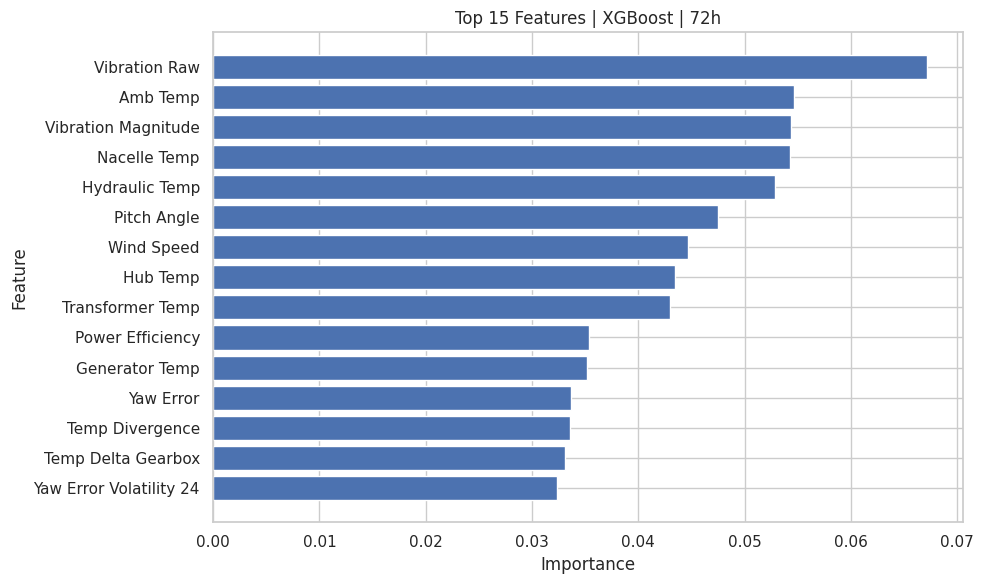

In [25]:
importance_df = report_diag["feature_importance_df"].copy()

value_col = "importance" if "importance" in importance_df.columns else "coefficient"
plot_importance_df = (
    importance_df
    .sort_values(value_col, ascending=False)
    .head(TOP_N_FEATURES)
    .iloc[::-1]
    .copy()
)
plot_importance_df["feature_display"] = plot_importance_df["feature"].map(clean_feature_name)

display(plot_importance_df.loc[:, ["feature", value_col]].sort_values(value_col, ascending=False))

fig_8_path = REPORT_FIG_DIR / "fig_8_feature_importance_plot.png"

plt.figure(figsize=(10, max(6, 0.35 * len(plot_importance_df))))
plt.barh(plot_importance_df["feature_display"], plot_importance_df[value_col])
plt.title(
    f"Top {TOP_N_FEATURES} Features | {prettify_model_name(REPORT_MODEL_NAME)} | "
    f"{prettify_experiment_name(REPORT_EXPERIMENT_NAME)}"
)
plt.xlabel("Importance" if value_col == "importance" else "Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

if SAVE_REPORT_FIGURES:
    plt.savefig(fig_8_path, dpi=300, bbox_inches="tight")
    report_asset_records.append({"asset": "Figure 8", "path": str(fig_8_path)})
    print(f"Saved figure to: {fig_8_path}")

plt.show()
plt.close()

## Report Outputs

This table lists the saved report figures and table exports produced by the notebook so they can be inserted directly into the written report.

In [26]:
report_asset_manifest_df = (
    pd.DataFrame(report_asset_records)
    .drop_duplicates()
    .sort_values("asset")
    .reset_index(drop=True)
)
display(report_asset_manifest_df)

,asset,path
0,Figure 1,/mnt/c/grad_school/northeastern/courses/ie7275...
1,Figure 2,/mnt/c/grad_school/northeastern/courses/ie7275...
2,Figure 2 data,/mnt/c/grad_school/northeastern/courses/ie7275...
3,Figure 3,/mnt/c/grad_school/northeastern/courses/ie7275...
4,Figure 4,/mnt/c/grad_school/northeastern/courses/ie7275...
5,Figure 4 data,/mnt/c/grad_school/northeastern/courses/ie7275...
6,Figure 5,/mnt/c/grad_school/northeastern/courses/ie7275...
7,Figure 5 data,/mnt/c/grad_school/northeastern/courses/ie7275...
8,Figure 6,/mnt/c/grad_school/northeastern/courses/ie7275...
9,Figure 7,/mnt/c/grad_school/northeastern/courses/ie7275...


## Summary

This notebook produces the full set of report-aligned visuals while preserving the modular project architecture:

- **Figure 1** explains the labeling strategy conceptually.
- **Figure 2** documents cross-farm feature availability and harmonization.
- **Figure 3** shows the class imbalance in the modeling dataset.
- **Figure 4** compares models for the representative 72-hour horizon.
- **Figure 5** compares XGBoost across all three prediction windows.
- **Figure 6** shows validation-set threshold behavior.
- **Figure 7** shows a representative predicted-probability timeline before failure.
- **Figure 8** summarizes the most influential XGBoost features.

The notebook still uses artifact guards for preprocessing and full experiment reuse, but now adds a targeted diagnostic run only where row-level predictions are required for the final report figures.

## Cleanup

The final cell releases large in-memory objects created for inspection. This is optional, but useful after a full run.

In [27]:
for var_name in [
    "sample_df",
    "master_df",
    "report_modeling_df",
    "timeline_predictions_df",
    "selected_timeline_df",
]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
print("Cleanup complete.")

Cleanup complete.
